# CA3 - Kaplan Meier survival curves

Link til Panopto video: [https://nmbu.cloud.panopto.eu/Panopto/Pages/Viewer.aspx?id=e6b27785-dafa-4253-b359-b4d500a518b3](https://nmbu.cloud.panopto.eu/Panopto/Pages/Viewer.aspx?id=e6b27785-dafa-4253-b359-b4d500a518b3)

## Background

During the first weeks of the course you have learned about the concepts of Kaplan Meier curves and how to produce them manually (without software packages) and using the lifelines. package. In this compulsory assignment you supposed apply this knowledge to analyse the following survival data on acquired from a study on colorectal cancer.  

<br>

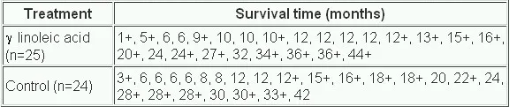  

As you can see from the data there are two groups, a control group with 24 patients and a treatment group with 25 patients that get a treatment based on linoleic acid. 

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from skrub import TableReport
import plotly.express as px
from lifelines import KaplanMeierFitter


## Fetching Data

In [2]:
# Manually create the treatment and control DataFrames
treatment = {
    "survival_time": [1, 5, 6, 6, 9, 10, 10, 10, 12, 12, 12, 12, 12, 13, 15, 16, 20, 24, 24, 27, 32, 34, 36, 36, 44],
    "event": [0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0]
}
treatment_df = pd.DataFrame(treatment)

control = {
    "survival_time": [3, 6, 6, 6, 6, 8, 8, 12, 12, 12, 15, 16, 18, 18, 20, 22, 24, 28, 28, 28, 30, 30, 33, 42],
    "event": [0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1]
}
control_df = pd.DataFrame(control)

## EDA

In [3]:
# Running df.describe() to get a summary of the treatment and control DataFrames with 2 decimals displayed
treatment_summary = treatment_df.describe()
control_summary = control_df.describe()

print("Treatment Summary:")
display(treatment_summary)

print("\nControl Summary:")
display(control_summary)

# Using skrub to create a summary report for both treatment and control groups
report_treatment = TableReport(treatment_df, title="Treatment Summary")
report_control = TableReport(control_df, title="Control Summary")
display(report_treatment)
display(report_control)

Treatment Summary:


,survival_time,event
count,25.000000,25.0
mean,17.520000,0.4
std,11.482305,0.5
min,1.000000,0.0
25%,10.000000,0.0
50%,12.000000,0.0
75%,24.000000,1.0
max,44.000000,1.0



Control Summary:


,survival_time,event
count,24.000000,24.000000
mean,17.958333,0.500000
std,10.564416,0.510754
min,3.000000,0.000000
25%,8.000000,0.000000
50%,17.000000,0.500000
75%,28.000000,1.000000
max,42.000000,1.000000


Processing column   2 / 2


<TableReport: use .open() or .markdown() to display>

Processing column   2 / 2


<TableReport: use .open() or .markdown() to display>

### Treatment Group Summary
* There is 25 patients in total.
* Average survival time is 17.52 months.
* Survival time range from 1 to 44 months.
* The median survival time in the raw data is 12 months.
* The event mean is 0.4 meaning 40% of the patient got the event.

### Control Group Summary
* There is 24 patient in total.
* Average survival time is 17.96 months. 0.44 months more than patients that got the treatment...
* Survival time range from 3 to 42 months.
    - So even though the minimum survival time was 3 months there was not recorded any patients having longer survival time than the longest treatment survival time.
    - This could be an issue resulting from lack of data.
* The median survival time in the raw data is 17 months.
    - This can indicate that half of the recorded patients that did not get the treatment has less survival time than the average patient that got the treatment.
    - However, Half of the recorded control patients has longer survival time than half of the recorded treatment patients.
* The event mean is 0.5 meaning 50% of the patient got the event. That is 10% more than the treatment group.

In [4]:
# Create a DataFrame for the treatment group
treatment_line = pd.DataFrame({
    "Patient": range(1, len(treatment_df) + 1),
    "Survival time": sorted(treatment_df["survival_time"]),
    "Group": "Treatment"
})

# Create a DataFrame for the control group
control_line = pd.DataFrame({
    "Patient": range(1, len(control_df) + 1),
    "Survival time": sorted(control_df["survival_time"]),
    "Group": "Control"
})

# Combine the treatment and control DataFrames for plotting
line_df = pd.concat([treatment_line, control_line])

# Create a line plot to visualize the survival times for both groups
fig = px.line(
    line_df,
    x="Patient",
    y="Survival time",
    color="Group",
    markers=True,
    title="Observed Survival Times by Group",
    labels={
        "Patient": "Patient (ordered by survival time)",
        "Survival time": "Survival time (months)"
    }
)

fig.show()

The plot shows overlap between the observed survival times of the treatment and control groups. The control group has some higher observed times in the lower and middle portions of the ordered data, while the treatment group has several higher observations toward the upper end.

## Task 1

Compute and report the average survival times and average hazards for both groups. Compute also the average hazard ratio for the two groups.

Q1: Looking at those numbers, what statement can you make regarding survival in each group?

In [5]:
average_survival_treatment = treatment_df["survival_time"].mean()
average_survival_control = control_df["survival_time"].mean()

events_treatment = treatment_df["event"].sum()
events_control = control_df["event"].sum()

total_time_treatment = treatment_df["survival_time"].sum()
total_time_control = control_df["survival_time"].sum()


In [6]:
average_hazard_treatment = events_treatment / total_time_treatment
average_hazard_control = events_control / total_time_control

results = pd.DataFrame({
    "Treatment": [
        average_survival_treatment,
        average_hazard_treatment
    ],
    "Control": [
        average_survival_control,
        average_hazard_control
    ]
}, index=[
    "Average survival time (months)",
    "Average hazard"
])

results

,Treatment,Control
Average survival time (months),17.520000,17.958333
Average hazard,0.022831,0.027842


In [7]:
hazard_ratio = average_hazard_treatment / average_hazard_control
print(f"Hazard ratio (Treatment / Control): {hazard_ratio:.3f}")

Hazard ratio (Treatment / Control): 0.820


- The average survival time is quite similar for both groups. The treatment group has an average survival time of 17.52 months, while the control group has 17.96 months. This means that on average the recorded survival time was about 17–18 months in both groups.
- The average hazard is 0.022831 for the treatment group and 0.027842 for the control group. Hazard describes the rate of events happening over the observed follow-up time. So that means the treatment group had about 0.0228 events per person-month, while the control group had about 0.0278 events per person-month.
- The hazard ratio is 0.82. This means that the calculated hazard in the treatment group was about 82% of the hazard in the control group. In other words, the treatment group had a lower observed event rate based on these calculations.

## Task 2

Show how you compute the estimated survival probability S(t) at each failure time and put the results in a table (as discussed in the lecture, see page 13 in lecture note 02-LN01-KaplanMeier & log-rank test). As an alternative to writing code you can write your computation on paper and take a photo of it and integrate it into the notebook. 

![image.png](task2.png)

## Task 3

From your computations in Task 2, draw the Kaplan-Meier survival curves for the control group and the treatment group. In this task you are not allowed to use any survival analysis packages such as lifelines or scikit-survival. It is OK to use matplotlib to plot the curve based on your results. It is also OK to draw the curve by hand on paper, take a photo and integrate it into the Jupyter notebook. In the curve draw a "+" onto the curve to indicate the censored patients.

Q2: What are the median survival times for each group?

![image.png](task3.png)

In the EDA, we found median observed survival times of 12 months for the treatment group and 17 months for the control group. However, these values differ from the Kaplan–Meier median survival times, since the Kaplan–Meier method accounts for censored observations. From the Kaplan–Meier curves, the median survival time is approximately 32 months for the treatment group and 30 months for the control group, where the curves reach a survival probability of 0.5. Comparing the two Kaplan–Meier curves, the treatment group has a slightly higher estimated median survival time than the control group. This means that, according to the Kaplan–Meier estimates, the point at which the estimated probability of surviving is 50% occurs slightly later for the treatment group. This suggests that the treatment may provide only a small survival benefit compared with the control group, since the estimated median survival times are very similar.

## Task 4

In the lecture we have used the lifelines package to draw the Kaplan Meier survival curve. In this task you are required to use the lifelines package to fit Kaplan-Meier estimators to the data and plot the curves. Provide also the median survival times computed by the lifelines Kaplan-Meier models. Check that the curves and median survival times from task 3 are the same as the one created here in task 4. Do not submit your Jupyter notebook if the results from Task 3 and Task 4 are different.

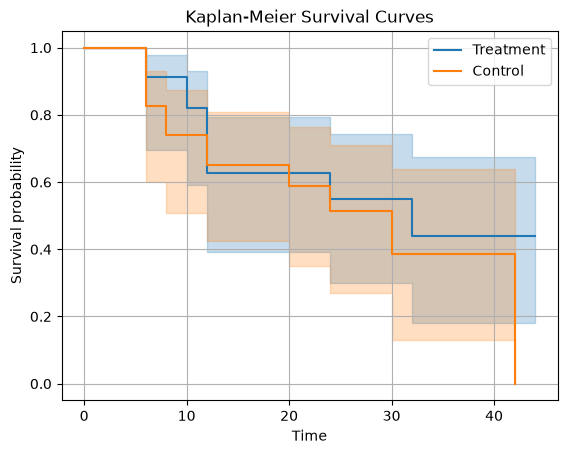

Median survival time - Treatment: 32.0
Median survival time - Control: 30.0


In [8]:
# Create Kaplan-Meier models
km_treatment = KaplanMeierFitter()
km_control = KaplanMeierFitter()

# Fit the models
km_treatment.fit(
    durations=treatment_df["survival_time"],
    event_observed=treatment_df["event"],
    label="Treatment"
)

km_control.fit(
    durations=control_df["survival_time"],
    event_observed=control_df["event"],
    label="Control"
)

# Plot the Kaplan-Meier curves
ax = km_treatment.plot()
km_control.plot(ax=ax)

plt.title("Kaplan-Meier Survival Curves")
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.grid(True)
plt.show()

# Median survival times
print("Median survival time - Treatment:", km_treatment.median_survival_time_)
print("Median survival time - Control:", km_control.median_survival_time_)

## AI Declaration

I used the AI tool ChatGPT to help improve the formulations of my answers to the questions Q1 - Q2. I also used the AI tool to help understand the Optuna documentation and the descriptions of the hyperparameters used in the optimisation process. The interpretation of the results are my own.